# Stage 1: Baseline Models

## Purpose

Stage 1 establishes the global baseline layer of the thesis pipeline. Its role is to learn contract-level structure from the weakly supervised contract universe, quantify how far weak supervision alone can go, and create a pretrained MLP backbone that Stage 2 meta-learning can adapt to individual departments.

## Stage 1 condition overview

The table below summarises the four experimental conditions. Each condition trains the same model family (Mean Predictor, Elastic Net, XGBoost, MLP) under a different supervision regime, allowing controlled ablation of weak vs. gold label value.

| Condition | Rows used | Target | Weighting | Scope | Target-dept gold excluded |
|-----------|-----------|--------|-----------|-------|---------------------------|
| **A** Weak-only | All contracts | `renegotiation_prob` (soft 0-1) | None (uniform) | Global | N/A (no gold used) |
| **B** Gold-only | Non-target-dept gold rows | `gold_y` (binary 0/1) | None (uniform) | Target-specific | Yes |
| **C** Hybrid (weighted) | All weak + non-target-dept gold | Mixed weak + gold | `w_gold` > `w_weak` via sampler | Target-specific | Yes |
| **D** Hybrid (unweighted) | All weak + non-target-dept gold | Mixed weak + gold | None (uniform) | Target-specific | Yes |

Key design points:

- **Condition A is global.** It uses all contracts and is reusable across target departments. Its artifacts are stored under `models/stage_1/global/A_weak_only/`.
- **Conditions B, C, D are target-aware.** They exclude the current target department's gold labels from training, reserving them for Stage 2. Their artifacts are stored under `models/stage_1/{target_department}/{condition}/`.
- **C and D share identical training data.** The only difference is whether `WeightedRandomSampler` upweights gold rows. Any performance gap isolates the effect of the weighting scheme alone.

<!--
FUTURE: synthetic-support planning table
When SMOTENC augmentation is implemented, a second summary table will connect
target department, real gold support size, synthetic proportion, and effective
support size for each department-as-target experiment.
-->

## Design principle

The Stage 1 design distinguishes between weak supervision and target-department gold supervision:

- All contracts (including the target department) remain in the Stage 1 weak-label universe.
- Weak labels generated by Snorkel remain part of Stage 1 weak training for all departments.
- The target department's gold labels are excluded from Stage 1 supervised gold training.
- The target department's gold labels are reserved for Stage 2 adaptation and evaluation.

This distinction is central to the thesis argument. Stage 1 should learn a global renegotiation representation, while Stage 2 should be the first point at which the model receives target-department gold signal.

## 1. Imports and project setup

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # ← tells OpenMP to allow duplicates


In [2]:
import sys
from pathlib import Path
import re

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(4) 


from master_thesis.config import FIGURES, MODELS_STAGE1, SEED
from master_thesis.data_utils import (
    load_processed,
    require_columns,
    make_gold_contract_split,
    save_table_versioned,
    save_json_versioned,
)
from master_thesis.baselines import (
    ElasticNetConfig,
    XGBoostConfig,
    BaselineTrainingConfig,
)
from master_thesis.mlp import (
    MLPTrainingConfig,
    set_seed,
)
from master_thesis.stage1 import (
    GLOBAL_CONDITIONS,
    Stage1ModelConfig,
    fit_stage1_conditions,
    evaluate_stage1_conditions,
    get_stage1_condition_dir,
    make_stage1_predictions_df,
    save_stage1_condition_artifacts,
    save_stage1_condition_summary,
    save_stage1_metadata,
)

## 2. Notebook Helpers

The helper functions below are kept in the notebook because they are specific to the Stage 1 experimental workflow. They handle feature availability flags, Stage 1 feature selection, and versioned figure export. Keeping them local makes the experimental setup easier to inspect and reproduce.


In [4]:
def get_stage1_feature_columns(
    df_input: pd.DataFrame,
    group_col: str,
    weak_target_col: str,
    gold_col: str,
) -> list[str]:
    leakage_cols = [
        "Unnamed: 0",
        group_col,
        "contract_number",
        "contract_name",
        "supplier_id",
        "supplier_number",
        "supplier_display_name",
        "moodys_bvd_id",
        "Company name Latin alphabet",
        "company_name",
        "gold_department",
        "target_renegotiate",
        weak_target_col,
        gold_col,
        "start_date",
        "expiration_date",
        "execution_at",
        "published_at",
        "contract_name_lower",
        "lf_yes_votes",
        "lf_no_votes",
        "lf_abstain_votes",
        "global_lifecycle_yes_votes",
        "global_lifecycle_no_votes",
        "global_financial_yes_votes",
        "global_financial_no_votes",
        "global_esg_yes_votes",
        "global_esg_no_votes",
        "global_news_yes_votes",
        "global_news_no_votes",
        "global_market_yes_votes",
        "global_market_no_votes",
        "global_supplier_macro_yes_votes",
        "global_supplier_macro_no_votes",
        "logistics_specific_yes_votes",
        "logistics_specific_no_votes",
    ]
    return [c for c in df_input.columns if c not in leakage_cols]


def save_figure_versioned(fig, stem: str, output_dir: Path | None = None, dpi: int = 300) -> Path:
    if output_dir is None:
        output_dir = FIGURES

    output_dir.mkdir(parents=True, exist_ok=True)
    pattern = re.compile(rf"^{re.escape(stem)}_v(\d{{3}})\.png$")
    versions = []

    for path in output_dir.glob(f"{stem}_v*.png"):
        match = pattern.match(path.name)
        if match:
            versions.append(int(match.group(1)))

    next_version = max(versions, default=0) + 1
    output_path = output_dir / f"{stem}_v{next_version:03d}.png"
    fig.savefig(output_path, bbox_inches="tight", dpi=dpi)
    return output_path


## 3. Data loading and Stage 1 setup

This section loads the weak-labeled dataset used by the Stage 1 baselines. The dataset contains the full contract universe with Snorkel probabilities and any available gold labels. The `TARGET_DEPARTMENT` variable below controls which department's gold labels are excluded from the supervised Stage 1 conditions (B, C, D) and reserved for Stage 2 adaptation.

In [5]:
set_seed(SEED)
np.random.seed(SEED)

# EXPERIMENT SETUP 1: Change dataset here
DATA_FILENAME = "contract_with_features_labeled_with_gold.csv"

# EXPERIMENT SETUP 2: Change weak target column here
WEAK_TARGET_COL = "renegotiation_prob"

# EXPERIMENT SETUP 3: Change gold target column here
GOLD_COL = "gold_y"
GROUP_COL = "contract_id"
DEPARTMENT_COL = "department"

df_stage1 = load_processed(DATA_FILENAME, low_memory=False)


In [6]:
# Stage 1 dataset diagnostics
print("Stage 1 dataset overview")
print(f"Total rows: {len(df_stage1)}")
print(f"Unique contracts: {df_stage1[GROUP_COL].nunique()}")

if DEPARTMENT_COL in df_stage1.columns:
    print("\nDepartment distribution (top 10)")
    print(df_stage1[DEPARTMENT_COL].value_counts().head(10))

print(f"\nWeak label column present ('{WEAK_TARGET_COL}'): {WEAK_TARGET_COL in df_stage1.columns}")
print(f"Gold label column present ('{GOLD_COL}'): {GOLD_COL in df_stage1.columns}")

Stage 1 dataset overview
Total rows: 9201
Unique contracts: 2209

Department distribution (top 10)
department
Devices & Needles                          2197
Raw Materials & Energy                     1555
Packaging Material                         1272
Quality, Production Services & Supplies    1044
Drug Substance Outsourcing                  943
Bioprocessing & Raw Materials               679
Drug Product Outsourcing                    589
Logistics                                   282
Alliance, Acquisitions & PPM CoE            270
Bioprocessing and Excipients                218
Name: count, dtype: int64

Weak label column present ('renegotiation_prob'): True
Gold label column present ('gold_y'): True


In [7]:
df_stage1.head()

,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,market_data_available,has_environmental_appendix,contract_name_lower,renegotiation_prob,target_renegotiate,gold_department,gold_y,label_source,label_date,notes
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
3,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
4,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.565277,1,NaN,NaN,NaN,NaN,NaN


In [8]:
require_columns(
    df_stage1,
    [WEAK_TARGET_COL, GOLD_COL, GROUP_COL, DEPARTMENT_COL],
    df_name="df_stage1",
)

print("Shape:", df_stage1.shape)
print("Unique contracts:", df_stage1[GROUP_COL].nunique())
print("Gold-labeled rows:", int(df_stage1[GOLD_COL].notna().sum()))
display(df_stage1.head(3))

Shape: (9201, 168)
Unique contracts: 2209
Gold-labeled rows: 700


,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,market_data_available,has_environmental_appendix,contract_name_lower,renegotiation_prob,target_renegotiate,gold_department,gold_y,label_source,label_date,notes
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN,NaN,NaN


## 3A. Gold split design and target-department handling

The split logic below implements the thesis data-separation rule for the current `TARGET_DEPARTMENT`.

The weak-label universe remains global, including the target department. This allows weak-only models to learn from the full contract portfolio and from the Snorkel probabilities assigned to all rows.

The supervised Stage 1 gold training sets exclude the target department. This prevents target-department gold leakage into Stage 1 while still allowing Stage 1 to serve as the global pretraining layer for Stage 2.

As a result:

- **Condition A** uses weak labels from all departments, including the target department.
- **Conditions B, C, D** use gold training labels only from non-target departments.
- Target-department gold labels are reserved for Stage 2.

This design generalises to any department-as-target experiment. To run Stage 1 for a different target department, change `TARGET_DEPARTMENT` and re-run the notebook.

In [9]:
# EXPERIMENT SETUP: Set the target department here.
# Change this variable to run Stage 1 for a different department-as-target.
TARGET_DEPARTMENT = "Logistics"

gold_train_contract_ids, gold_test_contract_ids = make_gold_contract_split(
    df_stage1=df_stage1,
    seed=SEED,
    test_size=0.30,
)

df_gold = df_stage1[df_stage1[GOLD_COL].notna()].copy()

# Reserve target-department gold labels for Stage 2 only.
df_gold_target = df_gold[df_gold[DEPARTMENT_COL] == TARGET_DEPARTMENT].copy()
df_gold_non_target = df_gold[df_gold[DEPARTMENT_COL] != TARGET_DEPARTMENT].copy()

df_gold_train = df_gold_non_target[df_gold_non_target[GROUP_COL].isin(gold_train_contract_ids)].copy()
df_gold_test = df_gold_non_target[df_gold_non_target[GROUP_COL].isin(gold_test_contract_ids)].copy()

# Weak training remains global and may include target-department weak labels.
# Only the held-out Stage 1 gold test contracts are removed from weak training.
df_weak_all = df_stage1.copy()
df_weak_train = df_weak_all[~df_weak_all[GROUP_COL].isin(gold_test_contract_ids)].copy()

print(f"Target department: {TARGET_DEPARTMENT}")
print(f"Gold train contracts before target exclusion: {len(gold_train_contract_ids)}")
print(f"Gold test contracts before target exclusion: {len(gold_test_contract_ids)}")
print(f"Non-target gold train rows: {len(df_gold_train)}")
print(f"Non-target gold test rows: {len(df_gold_test)}")
print(f"Target-department gold rows reserved for Stage 2: {len(df_gold_target)}")
print(f"Weak train rows: {len(df_weak_train)}")
print()

print("Non-target gold train label counts")
print(df_gold_train[GOLD_COL].value_counts(dropna=False))
print("\nNon-target gold test label counts")
print(df_gold_test[GOLD_COL].value_counts(dropna=False))

# Verify target-department exclusion from supervised splits.
if DEPARTMENT_COL in df_gold_train.columns:
    target_gold_train = int((df_gold_train[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())
    target_gold_test = int((df_gold_test[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())
    target_weak_train = int((df_weak_train[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())

    print(f"\nTarget-department separation diagnostics")
    print(f"  {TARGET_DEPARTMENT} rows in gold train: {target_gold_train}")
    print(f"  {TARGET_DEPARTMENT} rows in gold test:  {target_gold_test}")
    print(f"  {TARGET_DEPARTMENT} rows in weak train: {target_weak_train}")

    if target_gold_train > 0 or target_gold_test > 0:
        raise ValueError(
            f"{TARGET_DEPARTMENT} gold labels were found in Stage 1 supervised splits. "
            "These labels must be reserved for Stage 2."
        )

Target department: Logistics
Gold train contracts before target exclusion: 88
Gold test contracts before target exclusion: 38
Non-target gold train rows: 433
Non-target gold test rows: 207
Target-department gold rows reserved for Stage 2: 60
Weak train rows: 8968

Non-target gold train label counts
gold_y
1.0    266
0.0    167
Name: count, dtype: int64

Non-target gold test label counts
gold_y
0.0    124
1.0     83
Name: count, dtype: int64

Target-department separation diagnostics
  Logistics rows in gold train: 0
  Logistics rows in gold test:  0
  Logistics rows in weak train: 256


## 4. Feature matrix setup

After the split has enforced the target-department exclusion rule, this section constructs the Stage 1 feature matrices. The weak matrices remain global, whereas the supervised gold matrices are restricted to non-target-department gold rows. All downstream training conditions share the same preprocessing logic while respecting the thesis data-separation principle.

In [10]:
feature_cols = get_stage1_feature_columns(
    df_input=df_stage1,
    group_col=GROUP_COL,
    weak_target_col=WEAK_TARGET_COL,
    gold_col=GOLD_COL,
)

X_weak_train_df = df_weak_train[feature_cols].copy()
y_weak_train = df_weak_train[WEAK_TARGET_COL].astype(float).values

X_weak_all_df = df_weak_all[feature_cols].copy()
y_weak_all = df_weak_all[WEAK_TARGET_COL].astype(float).values

X_gold_train_df = df_gold_train[feature_cols].copy()
y_gold_train = df_gold_train[GOLD_COL].astype(int).values

X_gold_test_df = df_gold_test[feature_cols].copy()
y_gold_test = df_gold_test[GOLD_COL].astype(int).values

print("Number of Stage 1 features:", len(feature_cols))
print("Weak train shape:", X_weak_train_df.shape)
print("Gold train shape:", X_gold_train_df.shape)
print("Gold test shape :", X_gold_test_df.shape)

Number of Stage 1 features: 154
Weak train shape: (8968, 154)
Gold train shape: (433, 154)
Gold test shape : (207, 154)


## 5. Hyperparameters

This cell defines the Stage 1 training configuration for the baseline models and the MLP backbone. The purpose is not to perform exhaustive hyperparameter search, but to maintain a stable and reproducible configuration for comparing weak-only, gold-only, and hybrid supervision under a common experimental setting.


In [11]:
baseline_config = BaselineTrainingConfig(
    elastic_net=ElasticNetConfig(
        alpha=0.005,
        l1_ratio=0.5,
        max_iter=1000,         
        random_state=SEED,
    ),
    xgboost=XGBoostConfig(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=4,               
    ),
)


mlp_config = MLPTrainingConfig(
    n_epochs=100,
    patience=10,
    lr=5e-4,
    weight_decay=1e-4,
    train_batch_size=256,
    val_batch_size=512,
    hidden_dim_1=256,
    hidden_dim_2=128,
    dropout=0.1,
)

stage1_config = Stage1ModelConfig(
    baseline_config=baseline_config,
    mlp_config=mlp_config,
)

# EXPERIMENT SETUP 4: Change hybrid training weights here
HYBRID_WEAK_WEIGHT = 1.0
HYBRID_GOLD_WEIGHT = 5.0

experiment_config = {
    "seed": SEED,
    "data_filename": DATA_FILENAME,
    "weak_target_col": WEAK_TARGET_COL,
    "gold_col": GOLD_COL,
    "group_col": GROUP_COL,
    "department_col": DEPARTMENT_COL,
    "hybrid_weak_weight": HYBRID_WEAK_WEIGHT,
    "hybrid_gold_weight": HYBRID_GOLD_WEIGHT,
    "baseline_config": {
        "elastic_net": baseline_config.elastic_net.__dict__,
        "xgboost": baseline_config.xgboost.__dict__,
        "scale_numeric_for_elastic_net": baseline_config.scale_numeric_for_elastic_net,
        "scale_numeric_for_xgboost": baseline_config.scale_numeric_for_xgboost,
        "add_numeric_missing_indicator": baseline_config.add_numeric_missing_indicator,
    },
    "mlp_config": mlp_config.__dict__,
}

## 6. Define Stage 1 conditions

Four training conditions provide controlled experimental baselines. They isolate the contribution of each supervision source and allow direct ablation comparisons. The conditions are summarised in the table at the top of this notebook.

**Condition A -- Weak-only training (global)**
- **Target:** Snorkel probabilistic labels (`renegotiation_prob`, continuous 0-1) for every contract.
- Includes the target department's weak labels.
- Provides the main Stage 1 pretraining path and the principal initialisation candidate for Stage 2.
- Artifacts are stored under `models/stage_1/global/A_weak_only/` and are reusable across target departments.

**Condition B -- Gold-only training (target-aware)**
- **Target:** Binary hard labels (`gold_y`, 0/1) for non-target-department contracts only.
- Excludes target-department contracts entirely (held out for Stage 2 meta-testing).
- Ablation: how far does scarce gold supervision go on its own?

**Condition C -- Hybrid weighted (target-aware)**
- **Target:** Concatenation of weak labels (all rows) + gold labels (non-target-department rows only).
- `sample_weight` assigns `HYBRID_GOLD_WEIGHT` to gold rows and `HYBRID_WEAK_WEIGHT` to weak rows, activating `WeightedRandomSampler`.
- Ablation: does explicit up-weighting of gold labels improve alignment?

**Condition D -- Hybrid unweighted (target-aware)**
- **Target:** Identical concatenation to C -- the same `X_train` and `y_train` arrays.
- `sample_weight=None` -- uniform sampling, no `WeightedRandomSampler`.
- C and D share the same target definition. The difference is the *weighting scheme*, not a different objective. Any performance gap between C and D isolates the effect of the sampler alone.

In [12]:
conditions = {
    "A_weak_only": {
        "X_train_df": X_weak_train_df,
        "y_train": y_weak_train,
        "sample_weight": None,
    },
    "B_gold_only": {
        "X_train_df": X_gold_train_df,
        "y_train": y_gold_train.astype(float),
        "sample_weight": None,
    },
    "C_hybrid": {
        "X_train_df": pd.concat([X_weak_train_df, X_gold_train_df], axis=0).reset_index(drop=True),
        "y_train": np.concatenate([y_weak_train, y_gold_train.astype(float)]),
        "sample_weight": np.concatenate([
            np.full(len(y_weak_train), HYBRID_WEAK_WEIGHT, dtype=float),
            np.full(len(y_gold_train), HYBRID_GOLD_WEIGHT, dtype=float),
        ]),
    },    
    "D_hybrid_unweighted": {
        "X_train_df": pd.concat([X_weak_train_df, X_gold_train_df], axis=0).reset_index(drop=True),
        "y_train": np.concatenate([y_weak_train, y_gold_train.astype(float)]),
        "sample_weight": None, # The unweighted baseline (exactly the same as C, but with no weights!)
    },
}

## 7. Train All Stage 1 Conditions

Each Stage 1 condition trains the same family of baselines:

- Mean predictor
- Elastic Net
- XGBoost
- MLP

This consistent model menu ensures that differences in performance can be interpreted as differences in supervision regime rather than differences in model availability.


In [13]:
# Validation target design:
# - Condition A (weak-only): validate on gold targets, since gold-label
#   validity is the primary evaluation layer for all conditions.
# - Conditions B/C/D: validate on gold targets (consistent).
#
# The MLP uses BCEWithLogitsLoss for early stopping.  Using gold validation
# targets ensures the checkpoint selection optimises for real predictive
# quality rather than weak-label imitation.

trained_bundles = fit_stage1_conditions(
    conditions=conditions,
    X_val=X_gold_test_df,
    y_val=y_gold_test.astype(float),
    config=stage1_config,
    seed=SEED,
    verbose=True,
)


========== Starting Condition: A_weak_only ==========
[A_weak_only] Fitting Mean Predictor...
[A_weak_only] Mean Predictor fitting complete.
[A_weak_only] Fitting Elastic Net (this can take time if unscaled)...
[A_weak_only] Elastic Net fitting complete.
[A_weak_only] Fitting XGBoost...
[A_weak_only] XGBoost fitting complete.
[A_weak_only] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 0.5652 | Val Loss: 8.5317 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 02 | Train Loss: 0.5040 | Val Loss: 3.2553 | Val RMSE: 0.6329 | Val MAE: 0.4012
Epoch 03 | Train Loss: 0.4917 | Val Loss: 1.9723 | Val RMSE: 0.7192 | Val MAE: 0.6178
Epoch 04 | Train Loss: 0.4825 | Val Loss: 1.5925 | Val RMSE: 0.6144 | Val MAE: 0.4078
Epoch 05 | Train Loss: 0.4795 | Val Loss: 1.6392 | Val RMSE: 0.6112 | Val MAE: 0.4085
Epoch 06 | Train Loss: 0.4757 | Val Loss: 0.8073 | Val RMSE: 0.5283 | Val MAE: 0.4894
Epoch 07 | Train Loss: 0.4788 | Val Loss: 1.0924 | Val RMSE: 0.5728 | Val MAE: 0.4383
Epoch 08 | Train Loss: 0.4727 | 

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[B_gold_only] Elastic Net fitting complete.
[B_gold_only] Fitting XGBoost...


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[B_gold_only] XGBoost fitting complete.
[B_gold_only] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 0.6988 | Val Loss: 3.4626 | Val RMSE: 0.6331 | Val MAE: 0.4010
Epoch 02 | Train Loss: 0.6018 | Val Loss: 5.4810 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 03 | Train Loss: 0.5401 | Val Loss: 6.7493 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 04 | Train Loss: 0.4988 | Val Loss: 7.6071 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 05 | Train Loss: 0.4636 | Val Loss: 7.9743 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 06 | Train Loss: 0.4310 | Val Loss: 7.7847 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 07 | Train Loss: 0.3970 | Val Loss: 7.3710 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 08 | Train Loss: 0.3764 | Val Loss: 6.6802 | Val RMSE: 0.6332 | Val MAE: 0.4010
Epoch 09 | Train Loss: 0.3394 | Val Loss: 6.0093 | Val RMSE: 0.6332 | Val MAE: 0.4009
Epoch 10 | Train Loss: 0.3164 | Val Loss: 5.1605 | Val RMSE: 0.6318 | Val MAE: 0.4000
Epoch 11 | Train Loss: 0.2952 | Val Loss: 4.1040 | Val RMSE: 0.

## 8. Evaluate all trained conditions

Stage 1 evaluation is organised into two layers.

**Layer A: Weak-label distillation diagnostics.**
These metrics compare model predictions against Snorkel's `renegotiation_prob`. Their purpose is diagnostic: they measure how closely a model imitates the weak supervisor.

**Layer B: Gold-label validity.**
These metrics evaluate discrimination, ranking quality, probability calibration, and decision quality against held-out gold labels from non-target departments. This layer answers the more important question: whether a model trained under each supervision regime generalises to manually labelled contracts.

The Layer B results provide the empirical motivation for Stage 2. They show whether weak-only, gold-only, or hybrid Stage 1 training is sufficient, and therefore whether few-shot department adaptation remains necessary.

In [14]:
evaluation_results = evaluate_stage1_conditions(
    trained_bundles=trained_bundles,
    X_weak_eval=X_weak_all_df,
    y_weak_eval=y_weak_all,
    X_gold_eval=X_gold_test_df,
    y_gold_eval=y_gold_test,
    threshold=0.5,
    k_values=(5, 10, 20),
)

df_layer_a = evaluation_results["df_weak_results_all"].copy()
df_layer_b = evaluation_results["df_gold_results_all"].copy()

display(df_layer_a.sort_values(["rmse", "mae"], ascending=True))
display(df_layer_b.sort_values("gold_auroc", ascending=False))

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,rmse,mae,r2,pred_mean,true_mean,condition,model_base
2,XGBoost_A_weak_only,0.007396,0.002514,0.999420,0.549435,0.549803,A_weak_only,XGBoost
14,XGBoost_D_hybrid_unweighted,0.071818,0.024449,0.945322,0.546435,0.549803,D_hybrid_unweighted,XGBoost
10,XGBoost_C_hybrid,0.117917,0.040325,0.852599,0.546317,0.549803,C_hybrid,XGBoost
1,Elastic Net_A_weak_only,0.150132,0.112325,0.761057,0.545043,0.549803,A_weak_only,Elastic Net
13,Elastic Net_D_hybrid_unweighted,0.152052,0.114876,0.754906,0.544704,0.549803,D_hybrid_unweighted,Elastic Net
9,Elastic Net_C_hybrid,0.167021,0.126924,0.704274,0.547857,0.549803,C_hybrid,Elastic Net
11,MLP_C_hybrid,0.199688,0.131714,0.577282,0.476996,0.549803,C_hybrid,MLP
8,Mean Predictor_C_hybrid,0.307135,0.249261,-0.000008,0.548938,0.549803,C_hybrid,Mean Predictor
12,Mean Predictor_D_hybrid_unweighted,0.307135,0.249261,-0.000008,0.548938,0.549803,D_hybrid_unweighted,Mean Predictor
0,Mean Predictor_A_weak_only,0.307160,0.249180,-0.000171,0.545781,0.549803,A_weak_only,Mean Predictor


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20,condition,model_base
10,XGBoost_C_hybrid,0.906918,0.782377,1.026530,0.133634,0.176519,0.838710,0.855072,0.543202,0.400966,...,0.012048,0.714286,0.5,0.060241,0.714286,0.75,0.180723,0.714286,C_hybrid,XGBoost
6,XGBoost_B_gold_only,0.853187,0.673464,1.339364,0.164661,0.181171,0.788889,0.816425,0.515938,0.400966,...,0.048193,0.476190,0.8,0.096386,0.476190,0.50,0.120482,0.476190,B_gold_only,XGBoost
5,Elastic Net_B_gold_only,0.832103,0.694386,1.244464,0.185173,0.182741,0.720930,0.768116,0.484828,0.400966,...,0.060241,0.756757,1.0,0.120482,0.756757,1.00,0.240964,0.756757,B_gold_only,Elastic Net
14,XGBoost_D_hybrid_unweighted,0.775894,0.626387,1.187828,0.224629,0.235367,0.716981,0.710145,0.600517,0.400966,...,0.048193,0.562500,0.6,0.072289,0.562500,0.60,0.144578,0.587120,D_hybrid_unweighted,XGBoost
15,MLP_D_hybrid_unweighted,0.741935,0.689547,0.628940,0.219061,0.130802,0.112360,0.618357,0.375124,0.400966,...,0.048193,0.868795,0.9,0.108434,0.914857,0.80,0.192771,0.845098,D_hybrid_unweighted,MLP
11,MLP_C_hybrid,0.690439,0.590054,0.640962,0.224067,0.122913,0.545455,0.637681,0.456689,0.400966,...,0.060241,1.000000,0.7,0.084337,0.796761,0.65,0.156627,0.728639,C_hybrid,MLP
7,MLP_B_gold_only,0.559366,0.526139,3.462567,0.400816,0.400790,0.000000,0.599034,0.000176,0.400966,...,0.060241,1.000000,0.8,0.096386,0.860382,0.60,0.144578,0.701763,B_gold_only,MLP
9,Elastic Net_C_hybrid,0.533181,0.415405,1.316971,0.328279,0.237779,0.532110,0.507246,0.605896,0.400966,...,0.024096,0.375000,0.4,0.048193,0.392551,0.45,0.108434,0.433477,C_hybrid,Elastic Net
0,Mean Predictor_A_weak_only,0.500000,0.400966,0.715543,0.261164,0.144815,0.572414,0.400966,0.545781,0.400966,...,0.036145,0.400966,0.8,0.096386,0.400966,0.85,0.204819,0.400966,A_weak_only,Mean Predictor
4,Mean Predictor_B_gold_only,0.500000,0.400966,0.766093,0.285712,0.213353,0.572414,0.400966,0.614319,0.400966,...,0.036145,0.400966,0.8,0.096386,0.400966,0.85,0.204819,0.400966,B_gold_only,Mean Predictor


## 9. Save artifacts, metadata, and summary tables

This section saves all Stage 1 outputs needed by the rest of the thesis pipeline:

**Per-condition artifacts** (saved to `models/stage_1/{scope}/{condition}/`):
- `mlp_pretrained.pt` -- MLP weights for Stage 2 initialisation
- `mlp_pretrained_preprocessor.joblib` -- fitted preprocessor
- `mlp_pretrained_history.csv` -- MLP training history
- `tabular_results.csv` -- weak-distillation metrics (all models)
- `gold_results.csv` -- gold-label evaluation (Layer B)
- `predictions.csv` -- per-sample validation predictions (long format)
- `xgboost_feature_importance.csv` -- XGBoost feature importances
- `metadata.json` -- condition provenance and config snapshot

**Cross-condition:**
- `models/stage_1/condition_summary.csv` -- one row per (condition x model)

The artifact path convention uses `global/` for condition A and `{TARGET_DEPARTMENT}/` for conditions B, C, D, preventing silent overwrites when re-running for a different target department.

In [15]:
# ---------------------------------------------------------------------------
# Save all Stage 1 artifacts with target-aware directory structure
# ---------------------------------------------------------------------------

path_config  = save_json_versioned(experiment_config, "stage1_experiment_config")
path_layer_a = save_table_versioned(df_layer_a, "stage1_layer_a_weak_distillation")
path_layer_b = save_table_versioned(df_layer_b, "stage1_layer_b_gold_evaluation")

# Per-condition gold results, keyed by condition name.
gold_by_condition = evaluation_results["df_gold_results_by_condition"]

saved_condition_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    # Use the target-aware directory structure:
    #   global/A_weak_only/  for condition A
    #   {TARGET_DEPARTMENT}/B_gold_only/  for B, C, D
    condition_dir = get_stage1_condition_dir(
        base_dir=MODELS_STAGE1,
        condition_name=condition_name,
        target_department=TARGET_DEPARTMENT,
    )

    # Per-sample validation predictions for this condition.
    df_preds = make_stage1_predictions_df(
        trained_bundle=trained_bundle,
        X_eval=X_gold_test_df,
        y_true=y_gold_test,
        condition_name=condition_name,
    )

    saved_condition_paths[condition_name] = save_stage1_condition_artifacts(
        trained_bundle=trained_bundle,
        output_dir=condition_dir,
        save_xgb_importance=True,
        df_gold_results=gold_by_condition[condition_name],
        df_predictions=df_preds,
    )

    # Save per-condition metadata for reproducibility.
    metadata_path = save_stage1_metadata(
        output_dir=condition_dir,
        condition_name=condition_name,
        target_department=TARGET_DEPARTMENT,
        feature_count=len(feature_cols),
        config_snapshot=trained_bundle["config"],
        extra={
            "n_train_rows": len(conditions[condition_name]["X_train_df"]),
            "n_val_rows": len(X_gold_test_df),
            "has_sample_weight": conditions[condition_name].get("sample_weight") is not None,
            "seed": SEED,
        },
    )
    saved_condition_paths[condition_name]["metadata_path"] = metadata_path

    history_path = save_table_versioned(
        trained_bundle["mlp_bundle"]["history"],
        f"stage1_mlp_history_{condition_name}",
    )
    saved_condition_paths[condition_name]["history_versioned_path"] = history_path

# Cross-condition summary (one row per condition x model).
save_stage1_condition_summary(
    df_gold_results_all=evaluation_results["df_gold_results_all"],
    output_path=MODELS_STAGE1 / "condition_summary.csv",
)

print(f"\nSaved config:   {path_config}")
print(f"Saved layer A:  {path_layer_a}")
print(f"Saved layer B:  {path_layer_b}")
print(f"\nArtifact directories:")
for cond, paths in saved_condition_paths.items():
    scope = "global" if cond in GLOBAL_CONDITIONS else TARGET_DEPARTMENT
    print(f"  {cond} -> models/stage_1/{scope}/{cond}/")

Saved condition_summary.csv -> /Users/Thomas/Desktop/Master Thesis/models/stage_1/condition_summary.csv

Saved config:   /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_experiment_config_v021.json
Saved layer A:  /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_a_weak_distillation_v021.csv
Saved layer B:  /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_b_gold_evaluation_v021.csv

Artifact directories:
  A_weak_only -> models/stage_1/global/A_weak_only/
  B_gold_only -> models/stage_1/Logistics/B_gold_only/
  C_hybrid -> models/stage_1/Logistics/C_hybrid/
  D_hybrid_unweighted -> models/stage_1/Logistics/D_hybrid_unweighted/


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['avg_vol' 'vol_stability_score' 'vol_shock_ratio' 'vol_trend_slope'
 'market_cap_volatility' 'Price_trends_52 weeks_%'
 'Earnings_per_share_DKK' 'avg_closing_price' 'price_volatility_score'
 'price_trend_slope' 'market_log_vol_shock_ratio']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 10. Plots

The following plots summarize the main Stage 1 findings:

- weak-label distillation RMSE
- gold-label AUROC
- gold-label log-loss
- MLP training history for each condition

These figures support the written comparison between weak-only, gold-only, and hybrid supervision and help justify the transition from Stage 1 to Stage 2.


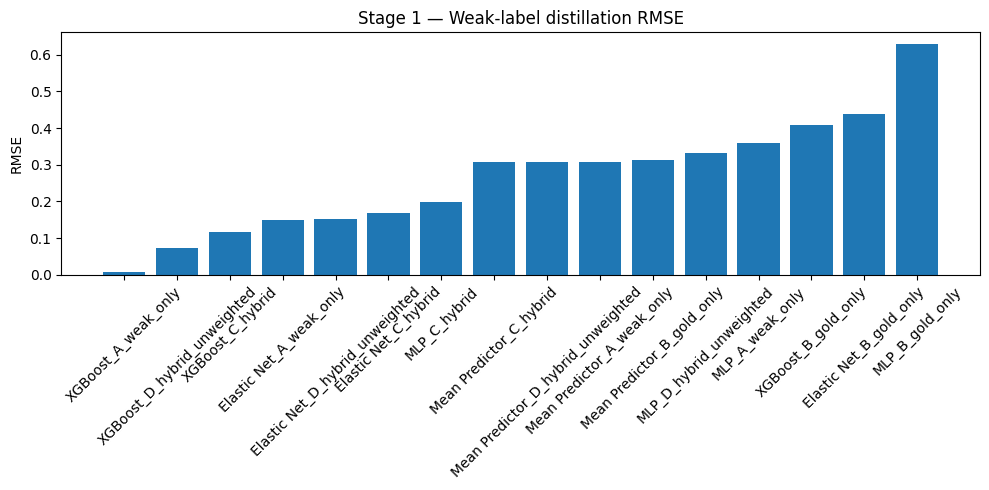

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_layer_a_rmse_v021.png


In [16]:
# --- Plot 1: Layer A weak-label RMSE
df_plot_a = df_layer_a.sort_values("rmse", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_a["model"], df_plot_a["rmse"])
ax.set_title("Stage 1 — Weak-label distillation RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_a = save_figure_versioned(fig, "stage1_layer_a_rmse")
plt.show()

print("Saved figure:", path_fig_a)

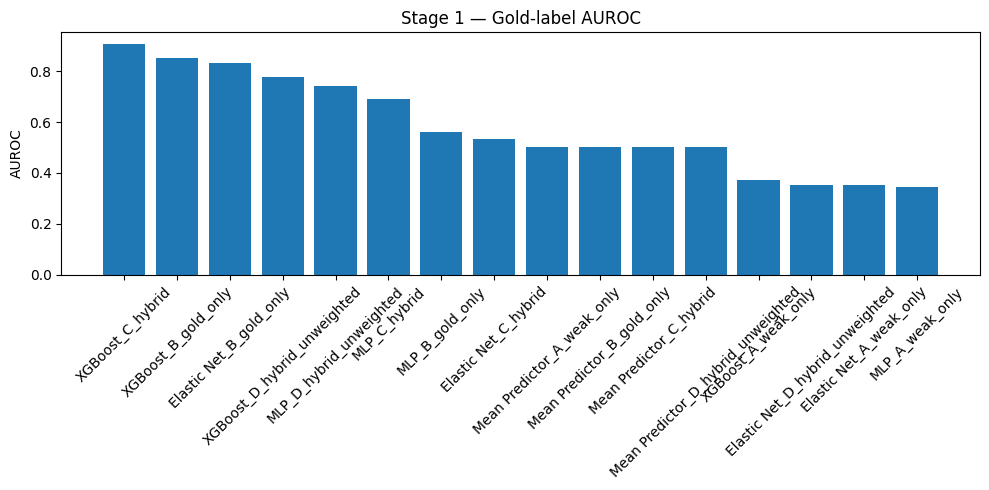

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_auroc_v021.png


In [17]:
# --- Plot 2: Layer B gold-label AUROC
df_plot_b_auc = df_layer_b.sort_values("gold_auroc", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_auc["model"], df_plot_b_auc["gold_auroc"])
ax.set_title("Stage 1 — Gold-label AUROC")
ax.set_ylabel("AUROC")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_auc = save_figure_versioned(fig, "stage1_gold_auroc")
plt.show()

print("Saved figure:", path_fig_b_auc)

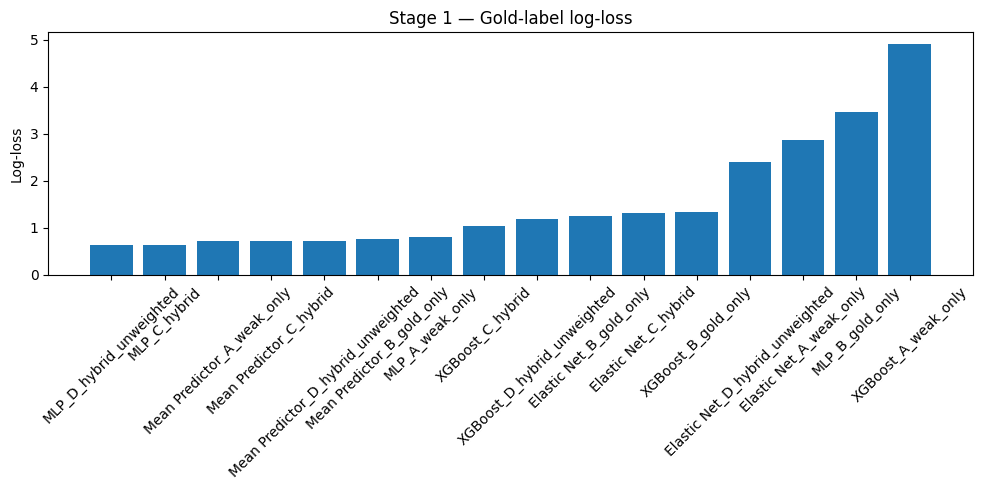

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_logloss_v021.png


In [18]:
# --- Plot 3: Layer B gold-label log-loss
df_plot_b_logloss = df_layer_b.sort_values("gold_logloss", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_logloss["model"], df_plot_b_logloss["gold_logloss"])
ax.set_title("Stage 1 — Gold-label log-loss")
ax.set_ylabel("Log-loss")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_logloss = save_figure_versioned(fig, "stage1_gold_logloss")
plt.show()

print("Saved figure:", path_fig_b_logloss)

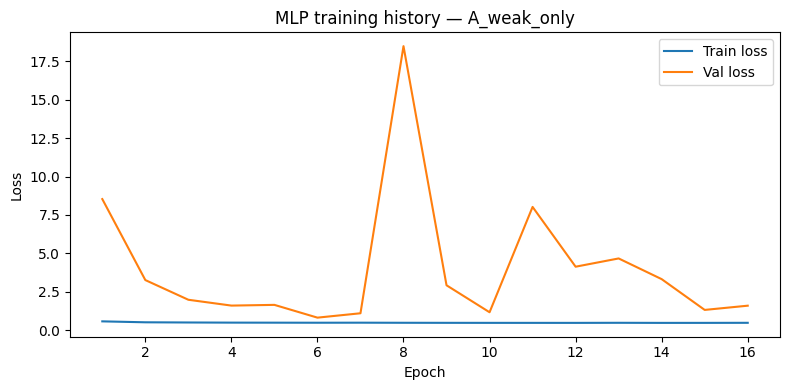

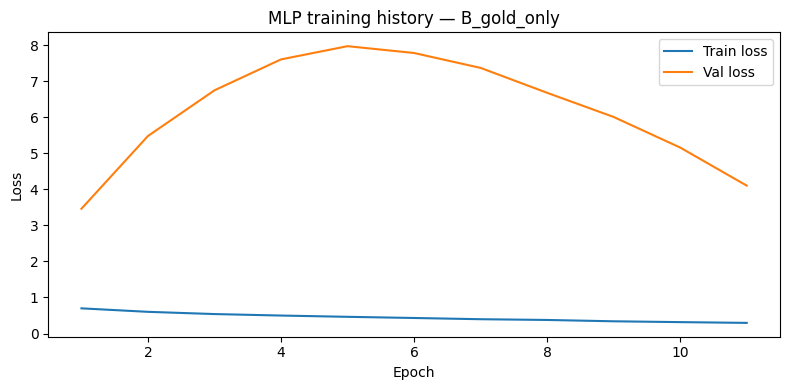

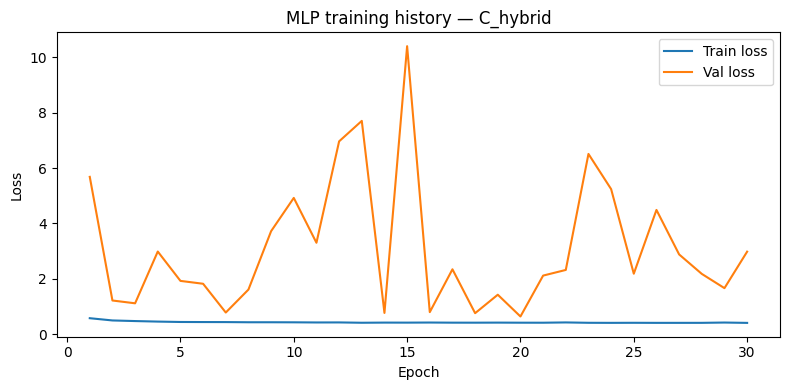

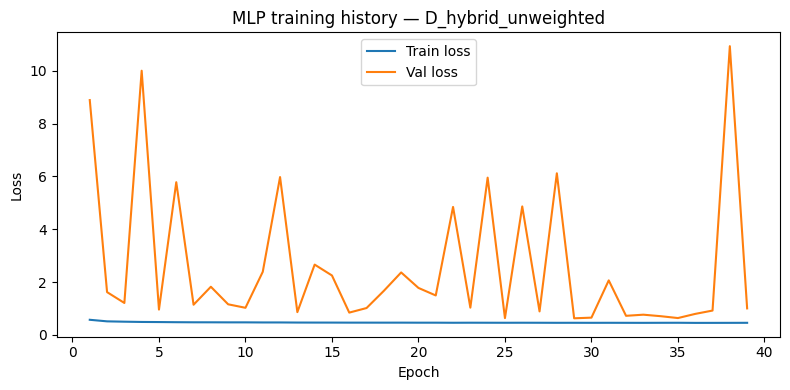

{'A_weak_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_A_weak_only_v021.png'),
 'B_gold_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_B_gold_only_v021.png'),
 'C_hybrid': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_C_hybrid_v021.png'),
 'D_hybrid_unweighted': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_D_hybrid_unweighted_v004.png')}

In [19]:
# --- Plot 4: MLP training history per condition
mlp_history_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    df_history = trained_bundle["mlp_bundle"]["history"].copy()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df_history["epoch"], df_history["train_loss"], label="Train loss")
    ax.plot(df_history["epoch"], df_history["val_loss"], label="Val loss")
    ax.set_title(f"MLP training history — {condition_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()

    fig_path = save_figure_versioned(fig, f"stage1_mlp_history_{condition_name}")
    mlp_history_paths[condition_name] = fig_path
    plt.show()

mlp_history_paths

## 11. Final summary views

The final tables consolidate the Stage 1 evidence base. They should be interpreted as the baseline layer that precedes Stage 2 adaptation. In particular, the summary should be read together with the design rule that the target department's weak labels were included in Stage 1, while its gold labels were held out from all supervised training conditions.

In [20]:
df_gold_summary = df_layer_b[
    [
        "model",
        "condition",
        "model_base",
        "gold_auroc",
        "gold_ap",
        "gold_logloss",
        "gold_brier",
        "gold_ece",
        "gold_f1",
        "gold_accuracy",
        "precision_at_5",
        "precision_at_10",
        "precision_at_20",
        "recall_at_5",
        "recall_at_10",
        "recall_at_20",
        "ndcg_at_5",
        "ndcg_at_10",
        "ndcg_at_20",
    ]
].copy()

display(df_gold_summary.sort_values(["gold_auroc", "gold_ap"], ascending=False))

,model,condition,model_base,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,precision_at_5,precision_at_10,precision_at_20,recall_at_5,recall_at_10,recall_at_20,ndcg_at_5,ndcg_at_10,ndcg_at_20
10,XGBoost_C_hybrid,C_hybrid,XGBoost,0.906918,0.782377,1.026530,0.133634,0.176519,0.838710,0.855072,0.2,0.5,0.75,0.012048,0.060241,0.180723,0.714286,0.714286,0.714286
6,XGBoost_B_gold_only,B_gold_only,XGBoost,0.853187,0.673464,1.339364,0.164661,0.181171,0.788889,0.816425,0.8,0.8,0.50,0.048193,0.096386,0.120482,0.476190,0.476190,0.476190
5,Elastic Net_B_gold_only,B_gold_only,Elastic Net,0.832103,0.694386,1.244464,0.185173,0.182741,0.720930,0.768116,1.0,1.0,1.00,0.060241,0.120482,0.240964,0.756757,0.756757,0.756757
14,XGBoost_D_hybrid_unweighted,D_hybrid_unweighted,XGBoost,0.775894,0.626387,1.187828,0.224629,0.235367,0.716981,0.710145,0.8,0.6,0.60,0.048193,0.072289,0.144578,0.562500,0.562500,0.587120
15,MLP_D_hybrid_unweighted,D_hybrid_unweighted,MLP,0.741935,0.689547,0.628940,0.219061,0.130802,0.112360,0.618357,0.8,0.9,0.80,0.048193,0.108434,0.192771,0.868795,0.914857,0.845098
11,MLP_C_hybrid,C_hybrid,MLP,0.690439,0.590054,0.640962,0.224067,0.122913,0.545455,0.637681,1.0,0.7,0.65,0.060241,0.084337,0.156627,1.000000,0.796761,0.728639
7,MLP_B_gold_only,B_gold_only,MLP,0.559366,0.526139,3.462567,0.400816,0.400790,0.000000,0.599034,1.0,0.8,0.60,0.060241,0.096386,0.144578,1.000000,0.860382,0.701763
9,Elastic Net_C_hybrid,C_hybrid,Elastic Net,0.533181,0.415405,1.316971,0.328279,0.237779,0.532110,0.507246,0.4,0.4,0.45,0.024096,0.048193,0.108434,0.375000,0.392551,0.433477
0,Mean Predictor_A_weak_only,A_weak_only,Mean Predictor,0.500000,0.400966,0.715543,0.261164,0.144815,0.572414,0.400966,0.6,0.8,0.85,0.036145,0.096386,0.204819,0.400966,0.400966,0.400966
4,Mean Predictor_B_gold_only,B_gold_only,Mean Predictor,0.500000,0.400966,0.766093,0.285712,0.213353,0.572414,0.400966,0.6,0.8,0.85,0.036145,0.096386,0.204819,0.400966,0.400966,0.400966


## 12. Stage 2 handoff

### Which Stage 1 artifacts does Stage 2 use?

Stage 2 (meta-learning) loads a single Stage 1 MLP artifact as its initialisation point. The key files are:

- `mlp_pretrained.pt` -- the pretrained MLP weights, used as the initial parameters for MAML/ANIL/FOMAML.
- `mlp_pretrained_preprocessor.joblib` -- the fitted sklearn preprocessor, reused so that Stage 2 features are transformed identically.
- `metadata.json` -- records the provenance of the initialisation (condition, target department, feature count, config).

### How target-aware variants matter for Stage 2

The primary Stage 2 initialisation comes from condition A (weak-only), because it is global and does not depend on which department is the target. This means the same A_weak_only artifact can be reused across all department-as-target experiments without retraining Stage 1.

Conditions B, C, and D are target-aware: their training data excludes the current target department's gold labels. If Stage 2 experiments need to compare initialisation sources (e.g., "does hybrid pretraining outperform weak-only pretraining for adaptation?"), these condition-specific artifacts provide the ablation baselines.

### Artifact path convention

Stage 2 should load artifacts using the same path logic:

```
models/stage_1/global/A_weak_only/mlp_pretrained.pt          # global, reusable
models/stage_1/{target_dept}/C_hybrid/mlp_pretrained.pt       # target-specific ablation
```

The `get_stage1_condition_dir()` helper in `stage1.py` encodes this convention and should be used by both Stage 1 and Stage 2 code to keep paths consistent.

### What Stage 1 does NOT do

Stage 1 does not perform any department-level adaptation. All Stage 1 models are trained on the global contract universe (or the non-target gold subset). The hypothesis that few-shot adaptation can close the remaining performance gap is tested exclusively in Stage 2.